# Projet IA

## Chargement Individuel des Datasets

### Importation des bibliothèques

In [65]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import make_scorer

import warnings
warnings.filterwarnings('ignore')


In [66]:
def build_time_features(df_in, df_out):
    in_datetimes = df_in.apply(pd.to_datetime, errors="coerce")
    out_datetimes = df_out.apply(pd.to_datetime, errors="coerce")

    in_minutes = in_datetimes.apply(
        lambda column: column.dt.hour * 60 + column.dt.minute + column.dt.second / 60
    )
    out_minutes = out_datetimes.apply(
        lambda column: column.dt.hour * 60 + column.dt.minute + column.dt.second / 60
    )
    work_duration_hours = (out_minutes - in_minutes) / 60

    return pd.DataFrame(
        {
            "InTimeAvgMinutes": in_minutes.mean(axis=1),
            "InTimeStdMinutes": in_minutes.std(axis=1),
            "InTimeMissingDays": in_minutes.isna().sum(axis=1),
            "OutTimeAvgMinutes": out_minutes.mean(axis=1),
            "OutTimeStdMinutes": out_minutes.std(axis=1),
            "OutTimeMissingDays": out_minutes.isna().sum(axis=1),
            "AvgWorkDurationHours": work_duration_hours.mean(axis=1),
            "StdWorkDurationHours": work_duration_hours.std(axis=1),
            "MissingWorkDurationDays": work_duration_hours.isna().sum(axis=1),
        }
    )

df_employee = pd.read_csv(
    "./Data/employee_survey_data.csv",
    sep=",",
    header=0,
    names=["EmployeeID","EnvironmentSatisfaction","JobSatisfaction","WorkLifeBalance"]
)
df_general = pd.read_csv(
    "./Data/general_data.csv",
    sep=",",
    header=0,
    names=["Age","Attrition","BusinessTravel","Department","DistanceFromHome","Education","EducationField","EmployeeCount","EmployeeID","Gender","JobLevel","JobRole","MaritalStatus","MonthlyIncome","NumCompaniesWorked","Over18","PercentSalaryHike","StandardHours","StockOptionLevel","TotalWorkingYears","TrainingTimesLastYear","YearsAtCompany","YearsSinceLastPromotion","YearsWithCurrManager"]
)
df_manager = pd.read_csv(
    "./Data/manager_survey_data.csv",
    sep=",",
    header=0,
    names=["EmployeeID","JobInvolvement","PerformanceRating"]
)
df_in = pd.read_csv("./Data/in_out_time/in_time.csv", sep=",", header=0, index_col=0)
df_out = pd.read_csv("./Data/in_out_time/out_time.csv", sep=",", header=0, index_col=0)
df_in.index.name = "EmployeeID"
df_out.index.name = "EmployeeID"
df_time_features = build_time_features(df_in, df_out)

# Imputer les valeurs manquantes pour chaque dataset
for df in [df_employee, df_general, df_manager, df_time_features]:
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    cat_cols = df.select_dtypes(include=['object']).columns
    if len(cat_cols) > 0:
        df[cat_cols] = df[cat_cols].fillna("Unknown")

## Fusion des datasets en un dataframe unique

In [67]:
# Fusionner les quatre sources en utilisant EmployeeID comme clé
# Tous les datasets partagent la même population d'employés, donc une fusion interne ne garde que les employés correspondants.
df_merged = (
    df_general
    .merge(df_employee, on='EmployeeID', how='inner')
    .merge(df_manager, on='EmployeeID', how='inner')
    .merge(df_time_features.reset_index(), on='EmployeeID', how='inner')
)
print('Taille du dataframe fusionné :', df_merged.shape)
print('Nombre d\'EmployeeID uniques :', df_merged['EmployeeID'].nunique())
print('Lignes avec EmployeeID en double :', df_merged.duplicated(subset=['EmployeeID']).sum())
print('\nColonnes du dataframe fusionné :')
print(df_merged.columns.tolist())

# Utiliser le dataframe fusionné pour le prétraitement et l'analyse ultérieurs
# Cela garde le dataset unifié et préserve les données d'enquête des employés, des managers et du temps.
df_general = df_merged.copy()

Taille du dataframe fusionné : (4410, 38)
Nombre d'EmployeeID uniques : 4410
Lignes avec EmployeeID en double : 0

Colonnes du dataframe fusionné :
['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeID', 'Gender', 'JobLevel', 'JobRole', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'Over18', 'PercentSalaryHike', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'InTimeAvgMinutes', 'InTimeStdMinutes', 'InTimeMissingDays', 'OutTimeAvgMinutes', 'OutTimeStdMinutes', 'OutTimeMissingDays', 'AvgWorkDurationHours', 'StdWorkDurationHours', 'MissingWorkDurationDays']


### Informations sur le dataset fusionné

In [68]:
print("Aperçu du dataframe fusionné")
print(df_general.head())
print("\nStatistiques descriptives")
print(df_general.describe())
print("\nInformations")
df_general.info()
print("\nValeurs manquantes par colonne")
print(df_general.isnull().sum())
print("\nLignes dupliquées")
print(df_general.duplicated().sum())

Aperçu du dataframe fusionné
   Age Attrition     BusinessTravel              Department  DistanceFromHome  \
0   51        No      Travel_Rarely                   Sales                 6   
1   31       Yes  Travel_Frequently  Research & Development                10   
2   32        No  Travel_Frequently  Research & Development                17   
3   38        No         Non-Travel  Research & Development                 2   
4   32        No      Travel_Rarely  Research & Development                10   

   Education EducationField  EmployeeCount  EmployeeID  Gender  ...  \
0          2  Life Sciences              1           1  Female  ...   
1          1  Life Sciences              1           2  Female  ...   
2          4          Other              1           3    Male  ...   
3          5  Life Sciences              1           4    Male  ...   
4          1        Medical              1           5    Male  ...   

   PerformanceRating InTimeAvgMinutes InTimeStdMinutes  I

In [69]:
print("Aperçu du dataset employee")
print(df_employee.head())
print("\nStatistiques descriptives")
print(df_employee.describe())
print("\nInformations")
df_employee.info()
print("\nValeurs manquantes par colonne")
print(df_employee.isnull().sum())
print("\nLignes dupliquées")
print(df_employee.duplicated().sum())

Aperçu du dataset employee
   EmployeeID  EnvironmentSatisfaction  JobSatisfaction  WorkLifeBalance
0           1                      3.0              4.0              2.0
1           2                      3.0              2.0              4.0
2           3                      2.0              2.0              1.0
3           4                      4.0              4.0              3.0
4           5                      4.0              1.0              3.0

Statistiques descriptives
        EmployeeID  EnvironmentSatisfaction  JobSatisfaction  WorkLifeBalance
count  4410.000000              4410.000000      4410.000000      4410.000000
mean   2205.500000                 2.725170         2.729478         2.763492
std    1273.201673                 1.089852         1.098904         0.703541
min       1.000000                 1.000000         1.000000         1.000000
25%    1103.250000                 2.000000         2.000000         2.000000
50%    2205.500000                 3.000

In [70]:
print("Aperçu du dataset manager")
print(df_manager.head())
print("\nStatistiques descriptives")
print(df_manager.describe())
print("\nInformations")
df_manager.info()
print("\nValeurs manquantes par colonne")
print(df_manager.isnull().sum())
print("\nLignes dupliquées")
print(df_manager.duplicated().sum())

Aperçu du dataset manager
   EmployeeID  JobInvolvement  PerformanceRating
0           1               3                  3
1           2               2                  4
2           3               3                  3
3           4               2                  3
4           5               3                  3

Statistiques descriptives
        EmployeeID  JobInvolvement  PerformanceRating
count  4410.000000     4410.000000        4410.000000
mean   2205.500000        2.729932           3.153741
std    1273.201673        0.711400           0.360742
min       1.000000        1.000000           3.000000
25%    1103.250000        2.000000           3.000000
50%    2205.500000        3.000000           3.000000
75%    3307.750000        3.000000           3.000000
max    4410.000000        4.000000           4.000000

Informations
<class 'pandas.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------ 

Comme nous pouvons le voir, les trois dataframes sont à peu près propres mais nous devons prétraiter df_general car il contient des données textuelles.

## Prétraitement du dataset Général

#### Suppression des colonnes non-RGPD

In [71]:
# Supprimer les colonnes Gender et EmployeeID
drop_columns = [col for col in ['Gender', 'EmployeeID', 'Over18', "EmployeeCount", "StandardHours"] if col in df_general.columns]
if drop_columns:
    df_general = df_general.drop(columns=drop_columns)
    print(f'Colonnes supprimées de df_general : {drop_columns}')
else:
    print('Colonnes déjà supprimées ou absentes')

# Supprimer uniquement les lignes strictement dupliquées,
# afin de ne pas perdre des employés qui partagent un profil RH identique mais sont bien distincts.
print(f"Lignes avant nettoyage: {df_general.shape[0]}")
original_count = df_general.shape[0]
df_general = df_general.drop_duplicates(keep='first').reset_index(drop=True)
print(f"Lignes après suppression des doublons exacts: {df_general.shape[0]}")
print(f"Doublons exacts supprimés: {original_count - df_general.shape[0]}")

Colonnes supprimées de df_general : ['Gender', 'EmployeeID', 'Over18', 'EmployeeCount', 'StandardHours']
Lignes avant nettoyage: 4410
Lignes après suppression des doublons exacts: 4410
Doublons exacts supprimés: 0


## Encodage des variables catégorielles

In [72]:
features_to_encode = [
    'BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus'
]
encoded = pd.get_dummies(df_general[features_to_encode], drop_first=True)

print(f"Variables catégorielles encodées: {encoded.shape[1]}")
print(encoded.head())

Variables catégorielles encodées: 19
   BusinessTravel_Travel_Frequently  BusinessTravel_Travel_Rarely  \
0                             False                          True   
1                              True                         False   
2                              True                         False   
3                             False                         False   
4                             False                          True   

   Department_Research & Development  Department_Sales  \
0                              False              True   
1                               True             False   
2                               True             False   
3                               True             False   
4                               True             False   

   EducationField_Life Sciences  EducationField_Marketing  \
0                          True                     False   
1                          True                     False   
2               

# Création de variables numériques

In [73]:
# Ingénierie des Caractéristiques
df_general['PromotionRatio'] = df_general['YearsSinceLastPromotion'] / (df_general['YearsAtCompany'] + 1)
df_general['IncomePerYearAge'] = df_general['MonthlyIncome'] / df_general['Age']
df_general['TenurePerJob'] = df_general['TotalWorkingYears'] / (df_general['NumCompaniesWorked'] + 1)

numeric_features = [
    "Age",
    "DistanceFromHome", 
    "Education", 
    "JobLevel", 
    "MonthlyIncome",
    "NumCompaniesWorked", 
    "PercentSalaryHike", 
    "StockOptionLevel",
    "TotalWorkingYears", 
    "TrainingTimesLastYear", 
    "YearsAtCompany",
    "YearsSinceLastPromotion", 
    "YearsWithCurrManager",
    # Caractéristiques d'enquête (manquantes)
    "EnvironmentSatisfaction", 
    "JobSatisfaction", 
    "WorkLifeBalance",
    "JobInvolvement", 
    "PerformanceRating",
    # Caractéristiques de temps
    "InTimeAvgMinutes", 
    "InTimeStdMinutes", 
    "InTimeMissingDays",
    "OutTimeAvgMinutes", 
    "OutTimeStdMinutes", 
    "OutTimeMissingDays",
    "AvgWorkDurationHours", 
    "StdWorkDurationHours", 
    "MissingWorkDurationDays",
    # Ingénierie
    "PromotionRatio", "IncomePerYearAge", "TenurePerJob",
]
numeric_features = [col for col in numeric_features if col in df_general.columns]

In [74]:
# Convertir Attrition en binaire: Oui -> 1, Non -> 0
df_general['Attrition_num'] = df_general['Attrition'].map({'Yes': 1, 'No': 0})

# Définir votre cible
multi_y = df_general['Attrition_num']

### Matrice de corrélation

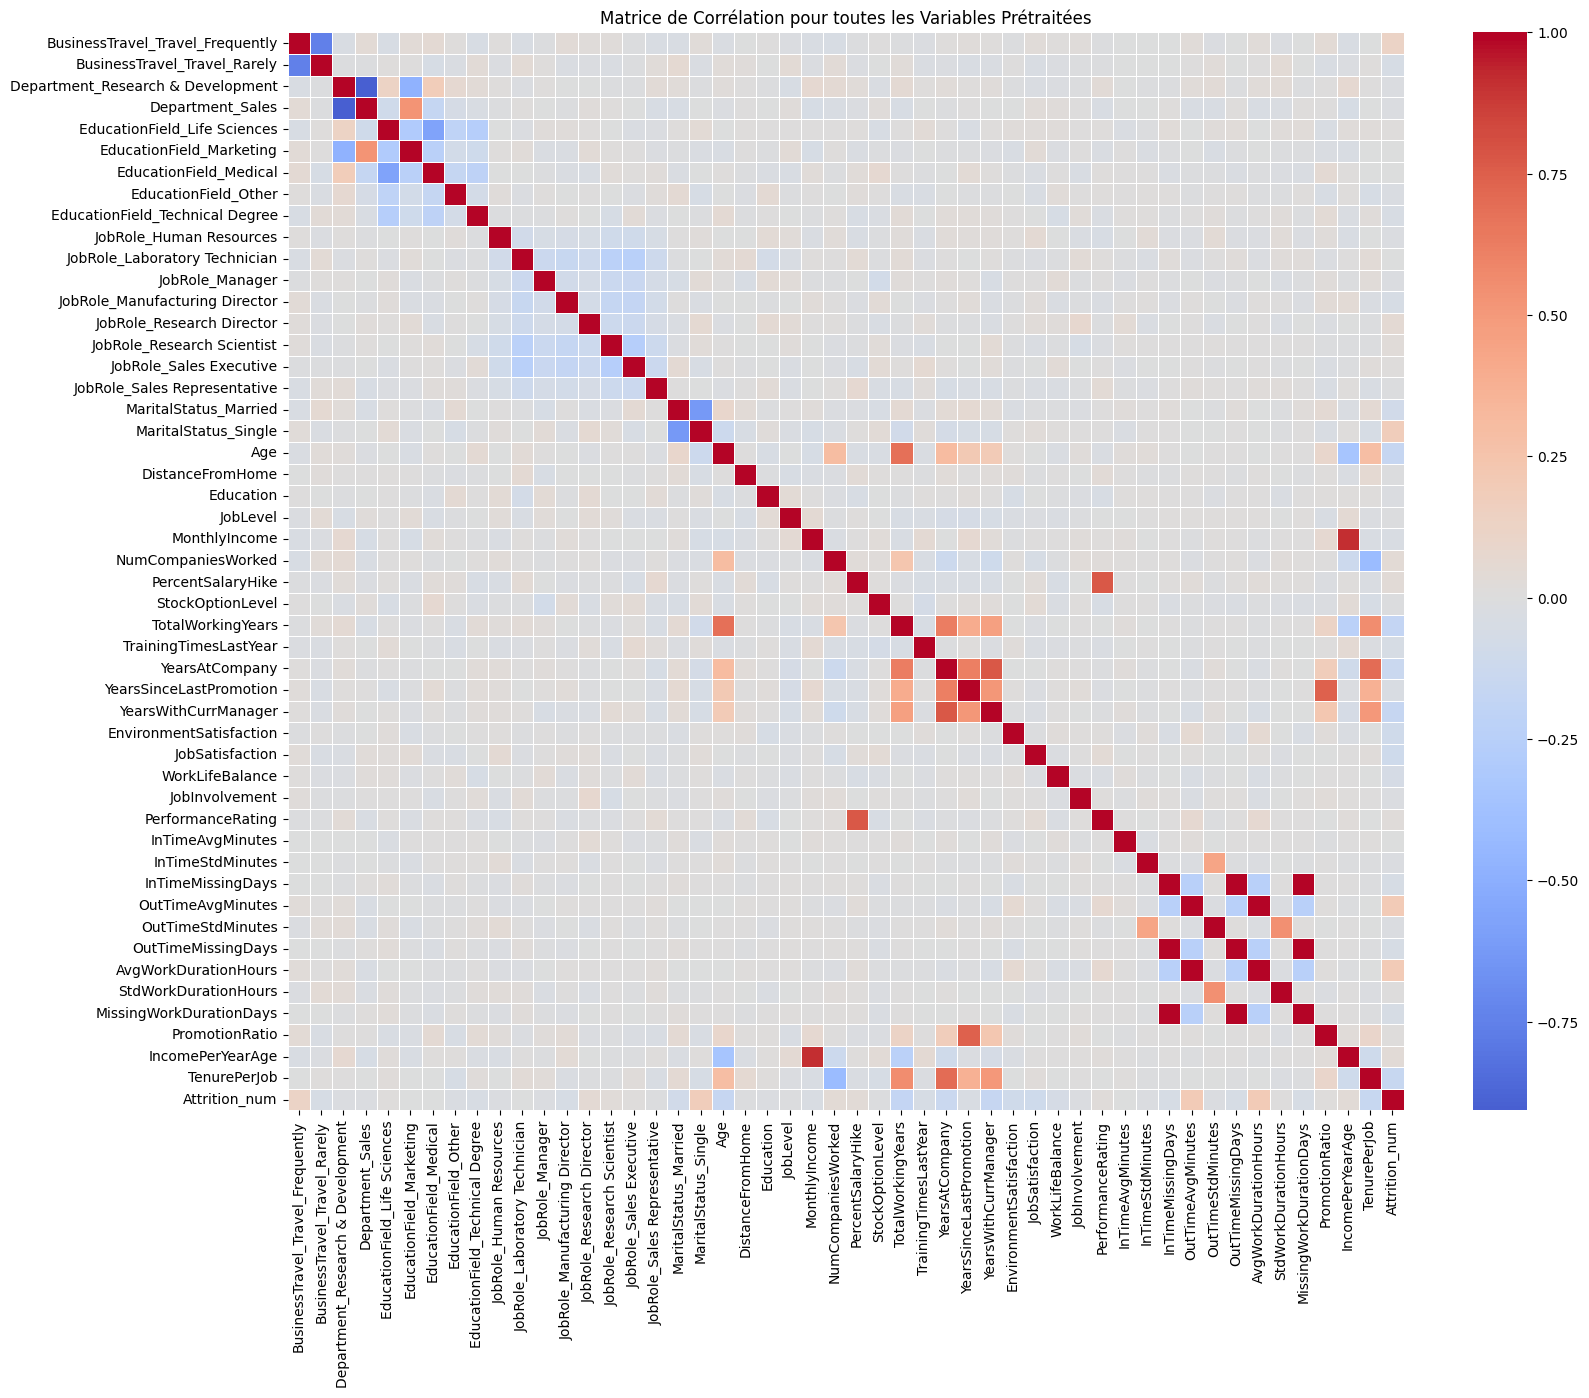

Plus fortes corrélations avec l'Attrition après prétraitement :
AvgWorkDurationHours                0.201688
OutTimeAvgMinutes                   0.201615
MaritalStatus_Single                0.175419
TotalWorkingYears                   0.170162
Age                                 0.159205
YearsWithCurrManager                0.156199
TenurePerJob                        0.149043
YearsAtCompany                      0.134392
BusinessTravel_Travel_Frequently    0.115143
JobSatisfaction                     0.103068
Name: Attrition_num, dtype: float64


In [75]:
# Calculer la matrice de corrélation avec les caractéristiques encodées et les caractéristiques numériques entières
corr_data = pd.concat([encoded, df_general[numeric_features]], axis=1)
if 'Attrition_num' in df_general.columns:
    corr_data['Attrition_num'] = df_general['Attrition_num']
else:
    corr_data['Attrition_num'] = df_general['Attrition'].map({'Yes': 1, 'No': 0})

# Supprimer les colonnes constantes avant de calculer la corrélation
corr_data = corr_data.loc[:, corr_data.nunique(dropna=True) > 1]

corr = corr_data.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matrice de Corrélation pour toutes les Variables Prétraitées')
plt.show()

# Afficher les corrélations les plus fortes avec Attrition
attrition_corr = corr['Attrition_num'].drop('Attrition_num')
print('Plus fortes corrélations avec l\'Attrition après prétraitement :')
print(attrition_corr.abs().sort_values(ascending=False).head(10))

## Boîtes à moustaches des variables numériques vs Attrition

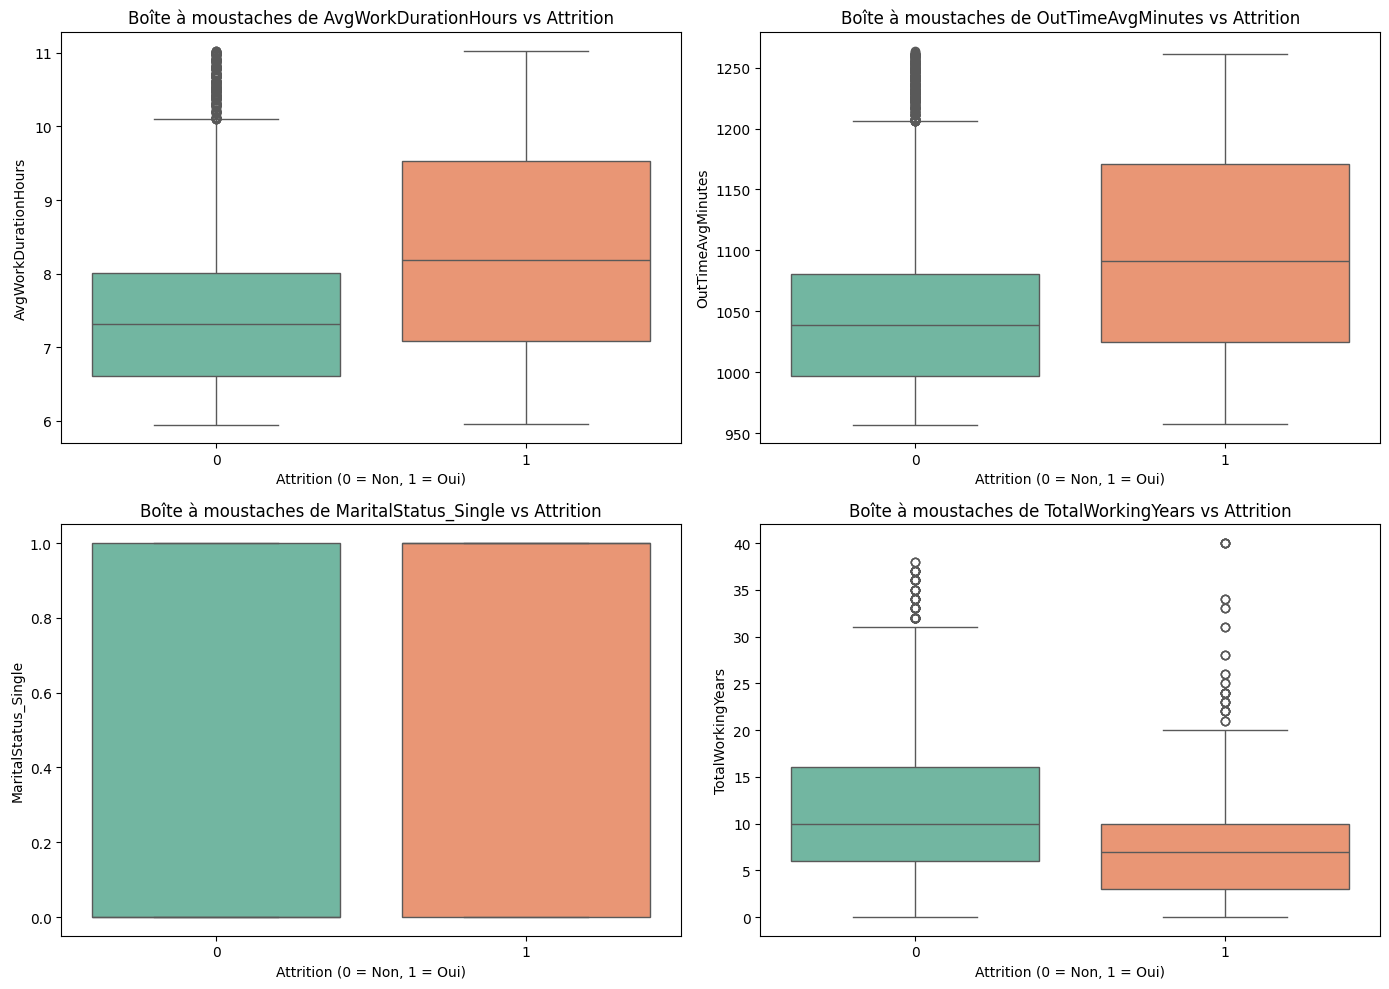

In [76]:
# Boxplots pour les 4 variables numériques les plus corrélées à l'Attrition
top_num_features = attrition_corr.abs().sort_values(ascending=False).head(4).index.tolist()

plt.figure(figsize=(14, 10))
for i, col in enumerate(top_num_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Attrition_num', y=col, hue='Attrition_num', data=corr_data, palette='Set2', legend=False)
    plt.title(f'Boîte à moustaches de {col} vs Attrition')
    plt.xlabel('Attrition (0 = Non, 1 = Oui)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

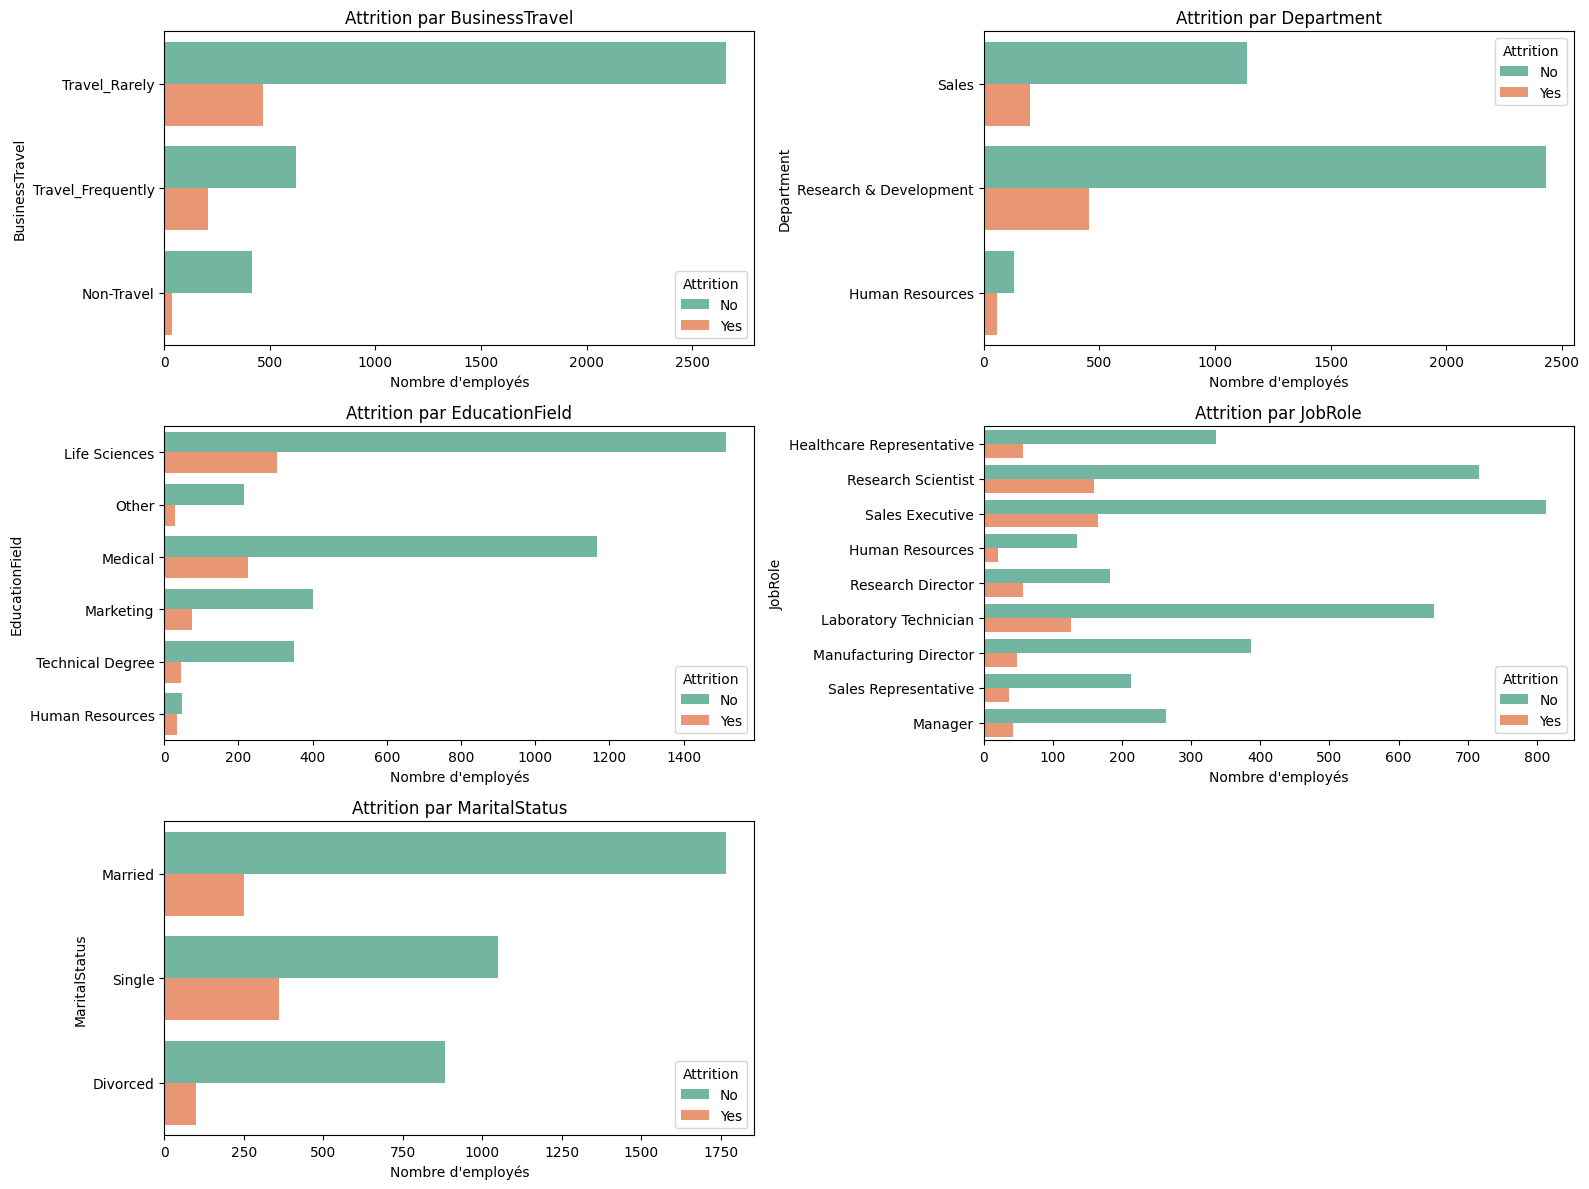

In [77]:
# Taux d'attrition sur les variables catégorielles (Barplots croisés)
plt.figure(figsize=(16, 12))
# features_to_encode contient ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
for i, col in enumerate(features_to_encode, 1):
    plt.subplot(3, 2, i)
    sns.countplot(y=col, hue='Attrition', data=df_general, palette='Set2')
    plt.title(f'Attrition par {col}')
    plt.xlabel("Nombre d'employés")
    plt.ylabel(col)
plt.tight_layout()
plt.show()

## Courbes de Régression Logistique

Meilleures caractéristiques utilisées pour la régression logistique: ['AvgWorkDurationHours', 'OutTimeAvgMinutes']


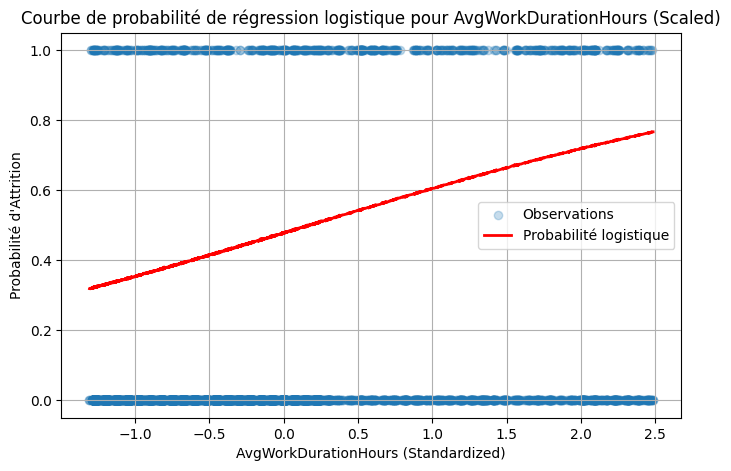

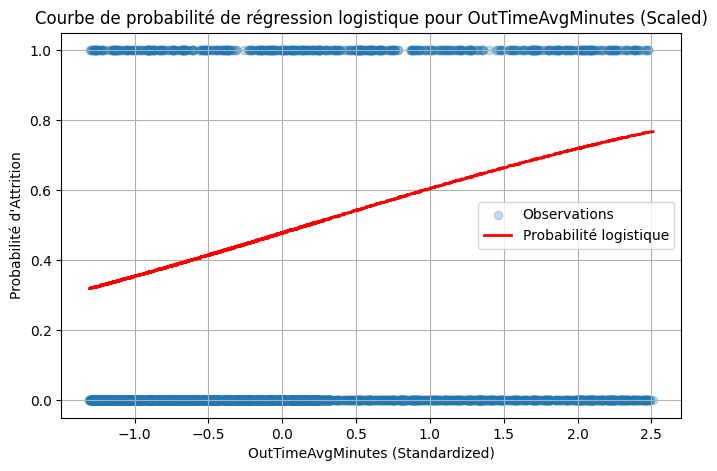

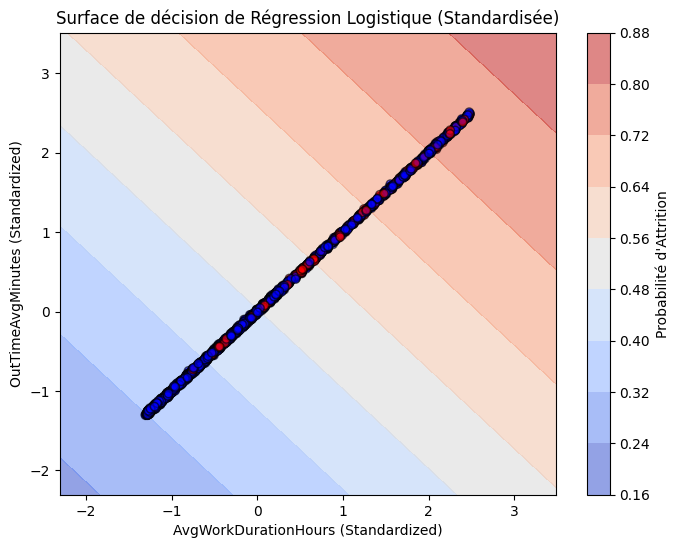

In [78]:
# Entraîner un modèle de régression logistique sur les deux caractéristiques les plus corrélées
top_features = attrition_corr.abs().sort_values(ascending=False).head(2).index.tolist()
print('Meilleures caractéristiques utilisées pour la régression logistique:', top_features)

X_log = corr_data[top_features]
y_log = corr_data['Attrition_num']

scaler_log = StandardScaler()
X_log_scaled = pd.DataFrame(scaler_log.fit_transform(X_log), columns=X_log.columns, index=X_log.index)

clf_log = LogisticRegression(max_iter=500, class_weight='balanced')
clf_log.fit(X_log_scaled, y_log)

# Tracer la courbe de probabilité pour chaque caractéristique principale séparément
for feature in top_features:
    plt.figure(figsize=(8, 5))
    idx = X_log_scaled[feature].sort_values().index
    values = X_log_scaled.loc[idx, feature].values
    probs = clf_log.predict_proba(X_log_scaled.loc[idx])[:, 1]
    plt.scatter(X_log_scaled[feature], y_log, alpha=0.25, label='Observations')
    plt.plot(values, probs, color='red', linewidth=2, label='Probabilité logistique')
    plt.title(f'Courbe de probabilité de régression logistique pour {feature} (Scaled)')
    plt.xlabel(f'{feature} (Standardized)')
    plt.ylabel('Probabilité d\'Attrition')
    plt.legend()
    plt.grid(True)
    plt.show()

# Si les deux caractéristiques sont numériques, afficher la limite de décision
if len(top_features) == 2:
    feature_x, feature_y = top_features
    x_min, x_max = X_log_scaled[feature_x].min() - 1, X_log_scaled[feature_x].max() + 1
    y_min, y_max = X_log_scaled[feature_y].min() - 1, X_log_scaled[feature_y].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_df = pd.DataFrame(grid, columns=[feature_x, feature_y])
    probs_grid = clf_log.predict_proba(grid_df)[:, 1].reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    contour = plt.contourf(xx, yy, probs_grid, cmap='coolwarm', alpha=0.6)
    plt.scatter(X_log_scaled[feature_x], X_log_scaled[feature_y], c=y_log, cmap='bwr', edgecolor='k', alpha=0.6)
    plt.colorbar(contour, label='Probabilité d\'Attrition')
    plt.title('Surface de décision de Régression Logistique (Standardisée)')
    plt.xlabel(f'{feature_x} (Standardized)')
    plt.ylabel(f'{feature_y} (Standardized)')
    plt.show()

# Préparation du Dataset

In [79]:
train_set = encoded.join(df_general[numeric_features])

# Division du Dataset

In [80]:
train_X, test_X,train_Y, test_Y = train_test_split(train_set, multi_y, test_size=0.2, random_state=1337, stratify=multi_y)

## Création d'un set de validation

In [81]:
multi_train_X, multi_val_X, multi_train_Y, multi_val_Y = train_test_split(train_X, train_Y, test_size=0.3, random_state=1337, stratify=train_Y)

scaler = StandardScaler()
multi_train_X_scaled = pd.DataFrame(scaler.fit_transform(multi_train_X), columns=multi_train_X.columns, index=multi_train_X.index)
multi_val_X_scaled = pd.DataFrame(scaler.transform(multi_val_X), columns=multi_val_X.columns, index=multi_val_X.index)
test_X_scaled = pd.DataFrame(scaler.transform(test_X), columns=test_X.columns, index=test_X.index)

## Modélisation et évaluation comparative

In [82]:
import json
import os
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

scale_pos_weight = float(np.sum(multi_train_Y == 0)) / np.sum(multi_train_Y == 1)
f1_leaver_scorer = make_scorer(f1_score, pos_label=1)

PARAMS_FILE = './Data/best_params.json'

# ============================================================
# Si le fichier existe → charger les paramètres sauvegardés
# Sinon → lancer GridSearchCV et sauvegarder les résultats
# ============================================================

if os.path.exists(PARAMS_FILE):
    print(f"Chargement des hyperparamètres depuis {PARAMS_FILE}...")
    with open(PARAMS_FILE, 'r') as f:
        saved = json.load(f)
    
    # Convertir les "None" string en vrais None Python
    for model_name in saved:
        for k, v in saved[model_name]['params'].items():
            if v == "None":
                saved[model_name]['params'][k] = None
    
    models = {
        'Logistic Regression': LogisticRegression(
            max_iter=2000, class_weight='balanced', random_state=1337,
            **saved['Logistic Regression']['params']
        ),
        'Random Forest': RandomForestClassifier(
            random_state=1337, class_weight='balanced',
            **saved['Random Forest']['params']
        ),
        'Gradient Boosting': GradientBoostingClassifier(
            random_state=1337,
            **saved['Gradient Boosting']['params']
        ),
        'XGBoost': XGBClassifier(
            eval_metric='logloss', random_state=1337,
            scale_pos_weight=scale_pos_weight,
            **saved['XGBoost']['params']
        ),
    }
    
    for name in models:
        print(f"  {name}: {saved[name]['params']}")

else:
    print(f"Fichier {PARAMS_FILE} non trouvé → lancement de GridSearchCV...\n")
    
    search_configs = {
        'Logistic Regression': {
            'model': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=1337),
            'params': {
                'C': [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
                'solver': ['lbfgs', 'liblinear'],
                'l1_ratio': [0.0, 0.5, 1.0],
            },
        },
        'Random Forest': {
            'model': RandomForestClassifier(random_state=1337, class_weight='balanced'),
            'params': {
                'n_estimators': [100, 200, 300, 500],
                'max_depth': [None, 10, 15, 20, 30],
                'min_samples_leaf': [1, 2, 3, 5],
                'min_samples_split': [2, 5, 10],
                'max_features': ['sqrt', 'log2', None],
            },
        },
        'Gradient Boosting': {
            'model': GradientBoostingClassifier(random_state=1337),
            'params': {
                'n_estimators': [100, 200, 300, 500],
                'max_depth': [3, 4, 5, 6, 7],
                'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
                'subsample': [0.7, 0.8, 0.9, 1.0],
                'min_samples_leaf': [1, 3, 5, 10],
            },
        },
        'XGBoost': {
            'model': XGBClassifier(
                eval_metric='logloss', random_state=1337,
                scale_pos_weight=scale_pos_weight,
            ),
            'params': {
                'n_estimators': [100, 200, 300],
                'max_depth': [4, 5, 6, 7],
                'learning_rate': [0.05, 0.1, 0.2],
                'subsample': [0.8, 0.9, 1.0],
                'colsample_bytree': [0.7, 0.8, 0.9],
                'min_child_weight': [1, 3, 5],
                'reg_alpha': [0, 0.1, 0.5],
                'reg_lambda': [1.0, 3.0, 5.0],
            },
        },
    }
    
    for name, config in search_configs.items():
        total = 1
        for values in config['params'].values():
            total *= len(values)
        print(f"{name}: {total} combinaisons × 5 folds = {total * 5} fits")
    
    models = {}
    saved = {}
    
    for name, config in search_configs.items():
        print(f"\nOptimisation de {name}...")
        
        search = GridSearchCV(
            estimator=config['model'],
            param_grid=config['params'],
            scoring=f1_leaver_scorer,
            cv=5,
            n_jobs=-1,
            verbose=1,
        )
        search.fit(multi_train_X_scaled, multi_train_Y)
        
        models[name] = search.best_estimator_
        
        # Convertir les paramètres pour JSON
        clean_params = {}
        for k, v in search.best_params_.items():
            if v is None:
                clean_params[k] = "None"
            elif hasattr(v, 'item'):
                clean_params[k] = v.item()
            else:
                clean_params[k] = v
        
        saved[name] = {
            'params': clean_params,
            'cv_f1_leaver': round(search.best_score_, 4),
        }
        
        print(f"  Meilleurs paramètres : {search.best_params_}")
        print(f"  Meilleur F1 Leaver CV : {search.best_score_:.4f}")
    
    with open(PARAMS_FILE, 'w') as f:
        json.dump(saved, f, indent=2)
    print(f"\nHyperparamètres sauvegardés dans {PARAMS_FILE}")

# ============================================================
# Entraîner, optimiser le seuil, et comparer
# ============================================================

results = []
for name, model in models.items():
    model.fit(multi_train_X_scaled, multi_train_Y)
    val_proba = model.predict_proba(multi_val_X_scaled)[:, 1]
    
    best_threshold = 0.5
    best_f1_leaver = 0.0
    for t in np.arange(0.15, 0.60, 0.01):
        val_pred_t = (val_proba >= t).astype(int)
        f1_leaver_t = f1_score(multi_val_Y, val_pred_t, pos_label=1)
        if f1_leaver_t > best_f1_leaver:
            best_f1_leaver = f1_leaver_t
            best_threshold = t
    
    val_preds = (val_proba >= best_threshold).astype(int)
    
    results.append({
        'Model': name,
        'Seuil': best_threshold,
        'Val F1 Leaver': best_f1_leaver,
        'Val Accuracy': accuracy_score(multi_val_Y, val_preds),
        'Val Recall Leaver': recall_score(multi_val_Y, val_preds, pos_label=1),
        'Val Prec Leaver': precision_score(multi_val_Y, val_preds, pos_label=1, zero_division=0),
    })

results_df = pd.DataFrame(results).sort_values(by='Val F1 Leaver', ascending=False)
print("\n" + results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
best_threshold = results_df.loc[results_df['Model'] == best_model_name, 'Seuil'].values[0]

print(f"\nModèle retenu : {best_model_name}")
print(f"Seuil retenu : {best_threshold:.2f}")

Chargement des hyperparamètres depuis ./Data/best_params.json...
  Logistic Regression: {'C': 0.05, 'solver': 'liblinear', 'l1_ratio': 1.0}
  Random Forest: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
  Gradient Boosting: {'learning_rate': 0.2, 'max_depth': 6, 'min_samples_leaf': 10, 'n_estimators': 300, 'subsample': 1.0}
  XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 100, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 1.0}

              Model  Seuil  Val F1 Leaver  Val Accuracy  Val Recall Leaver  Val Prec Leaver
            XGBoost   0.40       0.910180      0.971671           0.888889         0.932515
  Gradient Boosting   0.32       0.909091      0.971671           0.877193         0.943396
      Random Forest   0.45       0.839506      0.950897           0.795322         0.888889
Logistic Regression   0.59       0.526316      0.804533           

Évaluation sur le Set de Validation :
Exactitude (Accuracy) : 0.9717
Précision : 0.9713
Rappel (Recall) : 0.9717
F1-Score: 0.9714


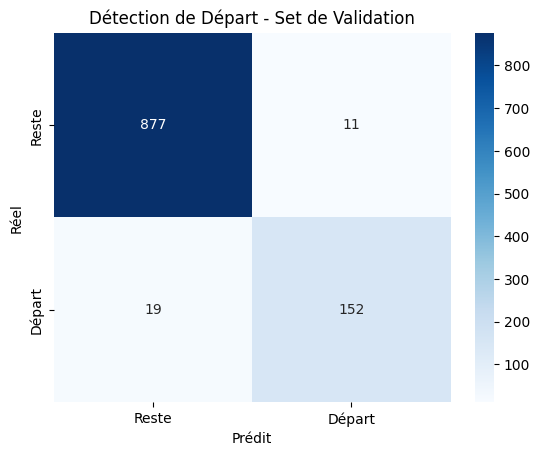

Rapport de Classification pour le Set de Validation :
              precision    recall  f1-score   support

       Reste       0.98      0.99      0.98       888
      Départ       0.93      0.89      0.91       171

    accuracy                           0.97      1059
   macro avg       0.96      0.94      0.95      1059
weighted avg       0.97      0.97      0.97      1059



In [83]:
# Prédire et évaluer le modèle sur l'ensemble de validation
multi_predictions = best_model.predict_proba(multi_val_X_scaled)[:, 1]
preds = (multi_predictions >= best_threshold).astype(int)
accuracy = accuracy_score(multi_val_Y, preds)
precision = precision_score(multi_val_Y, preds, average='weighted', zero_division=0)
recall = recall_score(multi_val_Y, preds, average='weighted', zero_division=0)
f1 = f1_score(multi_val_Y, preds, average='weighted', zero_division=0)
print(f"Évaluation sur le Set de Validation :")
print(f"Exactitude (Accuracy) : {accuracy:.4f}")
print(f"Précision : {precision:.4f}")
print(f"Rappel (Recall) : {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Matrice de Confusion pour l'ensemble de validation
conf_matrix = confusion_matrix(multi_val_Y, preds)
# 0 -> Reste (Non), 1 -> Départ (Oui)
class_labels = ['Reste', 'Départ']
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title(f'Détection de Départ - Set de Validation')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

# Rapport de Classification pour l'ensemble de validation
print("Rapport de Classification pour le Set de Validation :")
print(classification_report(multi_val_Y, preds, target_names=class_labels, zero_division=0))


Évaluation sur le Set de Test :
Seuil utilisé : 0.40
Exactitude (Accuracy) : 0.9966
Précision : 0.9966
Rappel (Recall) : 0.9966
F1-Score: 0.9966


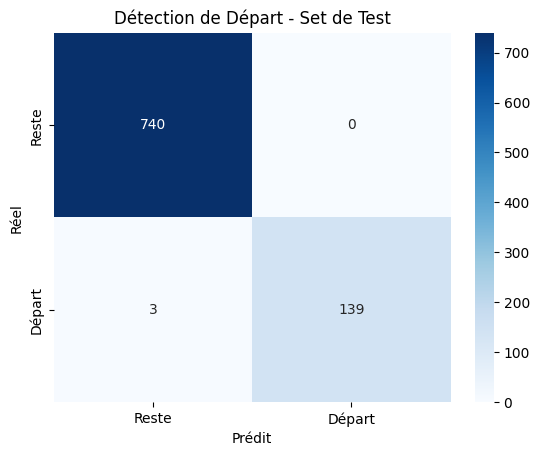

Rapport de Classification pour le Set de Test :
              precision    recall  f1-score   support

       Reste       1.00      1.00      1.00       740
      Départ       1.00      0.98      0.99       142

    accuracy                           1.00       882
   macro avg       1.00      0.99      0.99       882
weighted avg       1.00      1.00      1.00       882



In [84]:
# Évaluation finale sur l'ensemble de test
# 1. Réentraîner le normaliseur et le modèle sur l'ensemble d'entraînement complet 80% (Train + Validation)
final_scaler = StandardScaler()
full_train_X_scaled = pd.DataFrame(final_scaler.fit_transform(train_X), columns=train_X.columns, index=train_X.index)
test_X_scaled = pd.DataFrame(final_scaler.transform(test_X), columns=test_X.columns, index=test_X.index)

# IMPORTANT : réentraîner le modèle sur le train complet (80%) avec le nouveau scaler
best_model.fit(full_train_X_scaled, train_Y)

# Prédire avec le seuil optimisé (et non .predict() qui utilise 0.5)
test_proba = best_model.predict_proba(test_X_scaled)[:, 1]
test_multi_predictions = (test_proba >= best_threshold).astype(int)

test_accuracy = accuracy_score(test_Y, test_multi_predictions)
test_precision = precision_score(test_Y, test_multi_predictions, average='weighted', zero_division=0)
test_recall = recall_score(test_Y, test_multi_predictions, average='weighted', zero_division=0)
test_f1 = f1_score(test_Y, test_multi_predictions, average='weighted', zero_division=0)
print(f"\nÉvaluation sur le Set de Test :")
print(f"Seuil utilisé : {best_threshold:.2f}")
print(f"Exactitude (Accuracy) : {test_accuracy:.4f}")
print(f"Précision : {test_precision:.4f}")
print(f"Rappel (Recall) : {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")

# Matrice de Confusion pour l'ensemble de test
test_conf_matrix = confusion_matrix(test_Y, test_multi_predictions)
sns.heatmap(test_conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title(f'Détection de Départ - Set de Test')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

# Rapport de Classification pour l'ensemble de test
print("Rapport de Classification pour le Set de Test :")
print(classification_report(test_Y, test_multi_predictions, target_names=class_labels, zero_division=0))

## Courbe ROC & AUC

Score ROC AUC: 0.9893


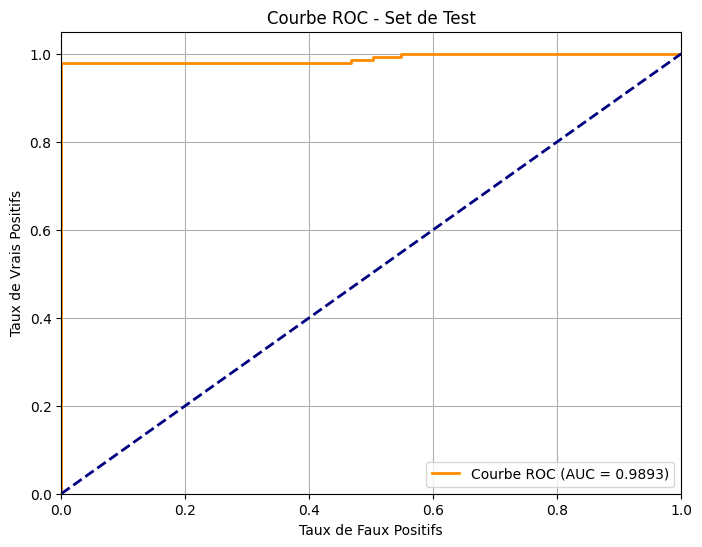

In [85]:
# Calculer les probabilités pour la classe positive
test_proba = best_model.predict_proba(test_X_scaled)[:, 1]

# Calculer l'AUC (Surface sous la courbe ROC)
roc_auc = roc_auc_score(test_Y, test_proba)
print(f"Score ROC AUC: {roc_auc:.4f}")

# Calculer les métriques de la courbe ROC
fpr, tpr, thresholds = roc_curve(test_Y, test_proba)

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbe ROC - Set de Test')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

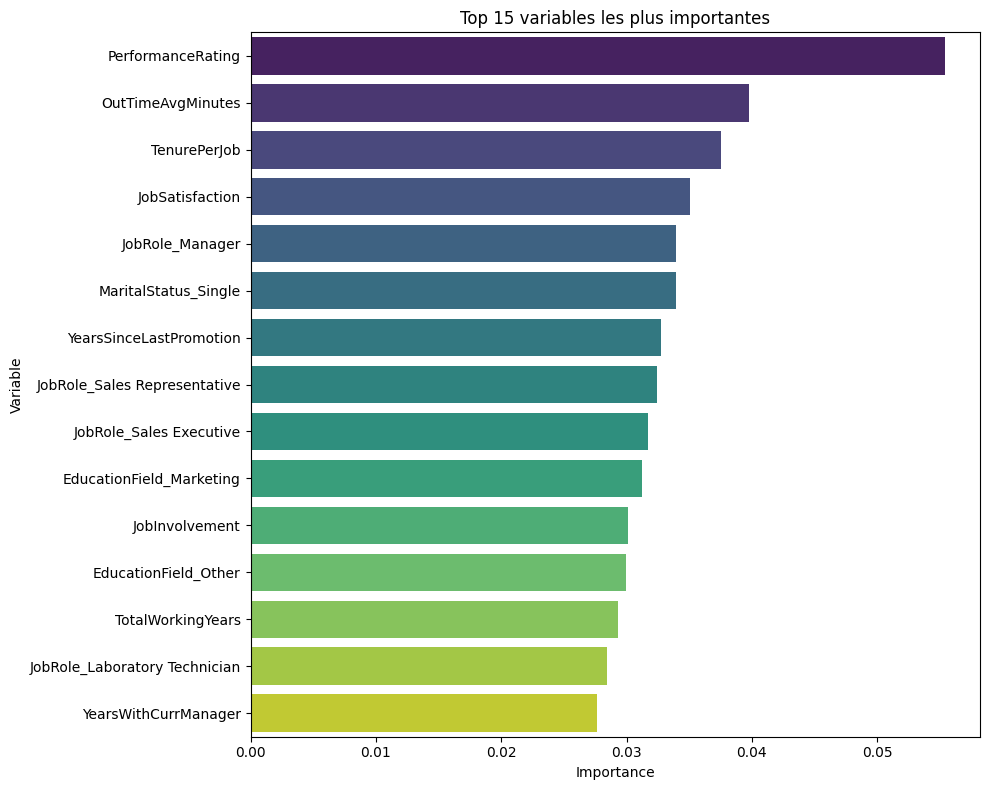

In [86]:
# Importance des variables du modèle retenu
importances = best_model.feature_importances_
feature_names = multi_train_X_scaled.columns

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances,
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    hue='Feature',
    data=feat_imp_df.head(15),
    palette='viridis',
    legend=False,
)
plt.title('Top 15 variables les plus importantes')
plt.xlabel("Importance")
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import learning_curve

print("Diagnostic de généralisation")
print(f"Modèle retenu: {best_model_name} (seuil={best_threshold:.2f})")


def evaluate_with_threshold(model, X, y, threshold):
    proba = model.predict_proba(X)[:, 1]
    preds = (proba >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y, preds),
        "F1 Leaver": f1_score(y, preds, pos_label=1),
        "Recall Leaver": recall_score(y, preds, pos_label=1),
        "Precision Leaver": precision_score(y, preds, pos_label=1, zero_division=0),
    }


sets = {
    "Train": (full_train_X_scaled, train_Y),
    "Validation": (multi_val_X_scaled, multi_val_Y),
    "Test": (test_X_scaled, test_Y),
}

metrics_by_set = {}
print("\nComparaison des performances")
print(f"{'Set':<12} {'Accuracy':>10} {'F1':>10} {'Recall':>10} {'Precision':>10}")
print("-" * 56)
for set_name, (X_set, y_set) in sets.items():
    metrics = evaluate_with_threshold(best_model, X_set, y_set, best_threshold)
    metrics_by_set[set_name] = metrics
    print(
        f"{set_name:<12} "
        f"{metrics['Accuracy']:>10.4f} "
        f"{metrics['F1 Leaver']:>10.4f} "
        f"{metrics['Recall Leaver']:>10.4f} "
        f"{metrics['Precision Leaver']:>10.4f}"
    )

# Gap principal: capacité à conserver la performance du train vers le test.
gap_f1 = metrics_by_set["Train"]["F1 Leaver"] - metrics_by_set["Test"]["F1 Leaver"]
gap_recall = metrics_by_set["Train"]["Recall Leaver"] - metrics_by_set["Test"]["Recall Leaver"]

print("\nÉcart Train -> Test")
print(f"F1 gap: {gap_f1:+.4f}")
print(f"Recall gap: {gap_recall:+.4f}")

if gap_f1 < 0.05:
    print("Conclusion: pas de surapprentissage marqué.")
elif gap_f1 < 0.10:
    print("Conclusion: surapprentissage léger, à surveiller.")
else:
    print("Conclusion: surapprentissage net, il faut régulariser le modèle.")

print("\nCourbes d'apprentissage (F1 weighted)")
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    multi_train_X_scaled,
    multi_train_Y,
    cv=5,
    scoring="f1_weighted",
    train_sizes=np.linspace(0.1, 1.0, 10),
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, "o-", color="tab:blue", label="Train")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.12, color="tab:blue")

plt.plot(train_sizes, val_mean, "o-", color="tab:red", label="Validation CV")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.12, color="tab:red")
test_metrics = metrics_by_set["Test"]
plt.axhline(y=test_metrics["F1 Leaver"], color="tab:green", linestyle="--", linewidth=1.5, label=f"Test F1 Leaver ({test_metrics['F1 Leaver']:.4f})")
plt.legend(loc="lower right")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("F1 weighted")
plt.title(f"Courbes d'apprentissage - {best_model_name}")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

final_curve_gap = train_mean[-1] - val_mean[-1]
print("Lecture rapide")
print(f"Gap final des learning curves (train - val): {final_curve_gap:.4f}")
print(f"Gap train -> test observé sur F1 Leaver: {gap_f1:.4f}")
if gap_f1 >= 0.10:
    print("Pistes: réduire la complexité (max_depth), augmenter la régularisation, ou simplifier les features.")

Diagnostic de généralisation
Modèle retenu: XGBoost (seuil=0.40)

Comparaison des performances
Set            Accuracy         F1     Recall  Precision
--------------------------------------------------------
Train            1.0000     1.0000     1.0000     1.0000


Validation       0.9575     0.8598     0.8070     0.9200
Test             0.9966     0.9893     0.9789     1.0000

Écart Train -> Test
F1 gap: +0.0107
Recall gap: +0.0211
Conclusion: pas de surapprentissage marqué.

Courbes d'apprentissage (F1 weighted)
